In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy.*")

import pymysql
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import ast 

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def get_db_connection():
    """建立 StarRocks 数据库连接"""
    return pymysql.connect(
        host='192.168.144.101',
        port=9030,
        user='hadoop',
        password='hadoop',
        charset='utf8'
    )

def fetch_and_process_data():
    """
    从 StarRocks 获取 Map 数据并在 Python 中完成聚合。
    """
    conn = get_db_connection()
    # 路径：catalog.db.table
    query = "SELECT decoration_distribution FROM iceberg_catalog.ershoufang.ads_city_overview_daily"
    
    try:
        # 获取原始数据
        df = pd.read_sql(query, conn)
        
        # 聚合逻辑：合并所有行中的 Map 计数
        total_counts = Counter()
        
        for item in df['decoration_distribution']:
            if not item:
                continue
            data = item
            if isinstance(item, str):
                try:
                    data = ast.literal_eval(item)
                except:
                    continue
            
            if isinstance(data, dict):
                total_counts.update(data)
        
        # 转换为 DataFrame 方便绘图
        result_df = pd.DataFrame(list(total_counts.items()), columns=['type', 'count'])
        return result_df.sort_values(by='count', ascending=False)
    
    finally:
        conn.close()

In [2]:
def plot_decoration_donut():
    """绘制带中心数值标注的空心环形图"""
    df = fetch_and_process_data()
    
    if df.empty:
        return

    # 数据准备
    labels = df['type']
    sizes = df['count']
    total_sum = sizes.sum()
    
    # 颜色设置
    colors = plt.cm.Paired(range(len(labels)))

    # --- 开始绘图 ---
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 1. 绘制饼图，通过 wedgeprops={'width': 0.3} 实现空心效果
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.85, 
        explode=[0.05] * len(labels),
        wedgeprops={'width': 0.3, 'edgecolor': 'w'}
    )

    # 2. 优化标注文字
    plt.setp(autotexts, size=10, weight="bold", color="white")
    plt.setp(texts, size=12)

    # 3. 中心数值标注
    ax.text(0, 0, f'总房源\n{int(total_sum)}', ha='center', va='center', 
            fontsize=15, fontweight='bold', color='#333333')

    # 4. 图表修饰
    plt.title('全国二手房装修分布概览', fontsize=16, pad=20)
    ax.legend(wedges, labels, title="装修类型", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

    plt.tight_layout()
    plt.show()

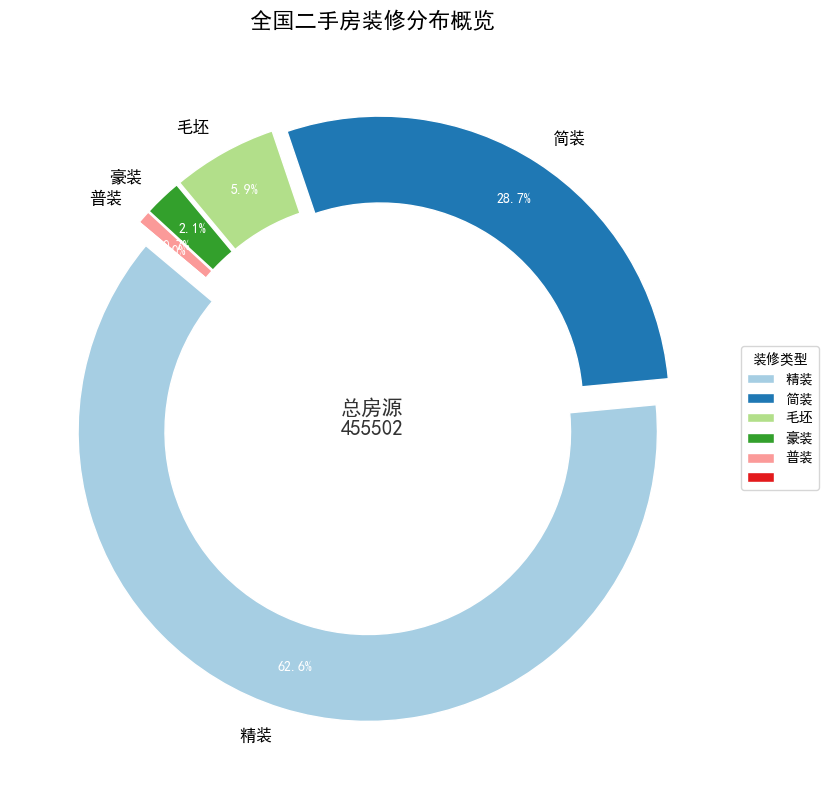

In [3]:
if __name__ == "__main__":
    plot_decoration_donut()